### Imports

In [2]:
from pathlib import Path
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

from pipeline import Pipeline
from lighting_filter import LightingFilter
from to_rgb import ToRGB
from skip_image import SkipImage

### Datasets

In [3]:
DATASETS = {
    "ferplus_train":   Path(r"C:\Users\drnes\Downloads\EmotionClassifier-main\EmotionClassifier-main\datasets\FERPlus\train"),
    "affectnet_train": Path(r"C:\Users\drnes\Downloads\EmotionClassifier-main\EmotionClassifier-main\datasets\AffectNet"),
}

### Image Paths

In [4]:
EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".webp"}

def collect_images(root: Path, max_files: int | None = None):
    paths = []
    for p in root.rglob("*"):
        if p.is_file() and p.suffix.lower() in EXTS:
            paths.append(p)
            if max_files is not None and len(paths) >= max_files:
                break
    return paths

for k, root in DATASETS.items():
    paths = collect_images(root, max_files=10)
    print(k, "example count:", len(paths))
    if paths:
        print(" example file:", paths[0])

ferplus_train example count: 10
 example file: C:\Users\drnes\Downloads\EmotionClassifier-main\EmotionClassifier-main\datasets\FERPlus\train\angry\augmented_1.png
affectnet_train example count: 10
 example file: C:\Users\drnes\Downloads\EmotionClassifier-main\EmotionClassifier-main\datasets\AffectNet\Train\anger\image0021840.jpg


### Display Helper

In [5]:
def show(img: np.ndarray, title=""):
    plt.figure(figsize=(4,4))
    plt.title(title)

    if img.ndim == 2:
        plt.imshow(img, cmap="gray")
    elif img.ndim == 3 and img.shape[2] >= 3:
        rgb = cv2.cvtColor(img[:, :, :3], cv2.COLOR_BGR2RGB)  # cv2 loads BGR
        plt.imshow(rgb)
    else:
        plt.imshow(img)

    plt.axis("off")
    plt.show()

### Lightning Filter Demo

In [ ]:
pipe = Pipeline([LightingFilter()])

def filter_rate(dataset_key: str, n: int = 2000):
    root = DATASETS[dataset_key]
    paths = collect_images(root, max_files=n)

    total = kept = filtered = failed = 0

    for p in paths:
        img = cv2.imread(str(p), cv2.IMREAD_UNCHANGED)
        if img is None:
            failed += 1
            continue

        total += 1
        try:
            _ = pipe.execute(img)
            kept += 1
        except SkipImage:
            filtered += 1

    pct = (filtered / total * 100) if total else 0
    print(dataset_key, f"total={total}, kept={kept}, filtered={filtered} ({pct:.2f}%), read_failed={failed}")

filter_rate("ferplus_train", n=2000)
filter_rate("affectnet_train", n=2000)

ferplus_train total=2000, kept=1997, filtered=3 (0.15%), read_failed=0
affectnet_train total=2000, kept=2000, filtered=0 (0.00%), read_failed=0


### Dropped Images (Lightning Filter)

In [ ]:
def find_dropped(dataset_key: str, max_scan: int = 50000, max_keep: int = 10, log_every: int = 500):
    root = DATASETS[dataset_key]
    paths = collect_images(root, max_files=max_scan)

    dropped = []
    scanned = 0

    for p in paths:
        scanned += 1
        if log_every and scanned % log_every == 0:
            print(f"{dataset_key}: scanned {scanned}/{len(paths)} | dropped so far {len(dropped)}")

        img = cv2.imread(str(p), cv2.IMREAD_UNCHANGED)
        if img is None:
            continue

        try:
            _ = pipe.execute(img)
        except SkipImage as e:
            dropped.append((p, str(e)))
            if len(dropped) >= max_keep:
                break

    print(f"{dataset_key} DONE | scanned={scanned} | dropped_found={len(dropped)}")
    return dropped

dropped_fer = find_dropped("ferplus_train", max_scan=50000, max_keep=10, log_every=500)
dropped_aff = find_dropped("affectnet_train", max_scan=50000, max_keep=10, log_every=500)

ferplus_train: scanned 500/50000 | dropped so far 1
ferplus_train: scanned 1000/50000 | dropped so far 2
ferplus_train: scanned 1500/50000 | dropped so far 3
ferplus_train: scanned 2000/50000 | dropped so far 3
ferplus_train: scanned 2500/50000 | dropped so far 4
ferplus_train: scanned 3000/50000 | dropped so far 4
ferplus_train: scanned 3500/50000 | dropped so far 4
ferplus_train: scanned 4000/50000 | dropped so far 4
ferplus_train: scanned 4500/50000 | dropped so far 5
ferplus_train: scanned 5000/50000 | dropped so far 5
ferplus_train: scanned 5500/50000 | dropped so far 5
ferplus_train: scanned 6000/50000 | dropped so far 5
ferplus_train: scanned 6500/50000 | dropped so far 5
ferplus_train: scanned 7000/50000 | dropped so far 5
ferplus_train: scanned 7500/50000 | dropped so far 5
ferplus_train: scanned 8000/50000 | dropped so far 5
ferplus_train: scanned 8500/50000 | dropped so far 5
ferplus_train: scanned 9000/50000 | dropped so far 5
ferplus_train: scanned 9500/50000 | dropped so 

### Show Dropped Images (Lightning Filter)

FERPlus dropped examples:

DROPPED: C:\Users\drnes\Downloads\EmotionClassifier-main\EmotionClassifier-main\datasets\FERPlus\train\angry\augmented_1101.png
Reason : Too many bright pixels (white_frac=0.64)
Shape  : (112, 112) | dtype: uint8


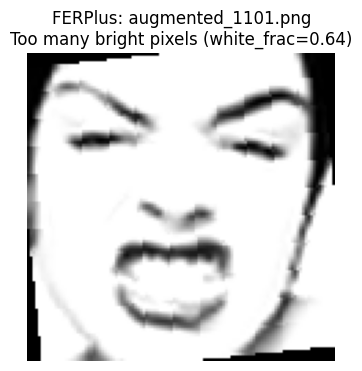


DROPPED: C:\Users\drnes\Downloads\EmotionClassifier-main\EmotionClassifier-main\datasets\FERPlus\train\angry\augmented_1545.png
Reason : Too many bright pixels (white_frac=0.65)
Shape  : (112, 112) | dtype: uint8


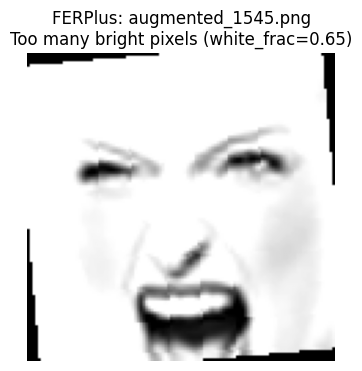


DROPPED: C:\Users\drnes\Downloads\EmotionClassifier-main\EmotionClassifier-main\datasets\FERPlus\train\angry\augmented_2113.png
Reason : Too many bright pixels (white_frac=0.63)
Shape  : (112, 112) | dtype: uint8


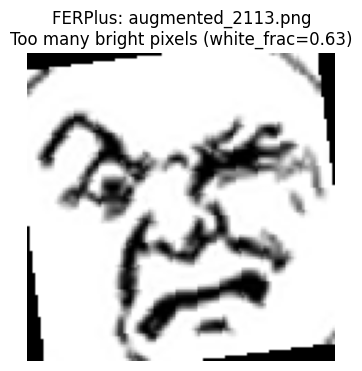


DROPPED: C:\Users\drnes\Downloads\EmotionClassifier-main\EmotionClassifier-main\datasets\FERPlus\train\angry\augmented_3172.png
Reason : Too many bright pixels (white_frac=0.74)
Shape  : (112, 112) | dtype: uint8


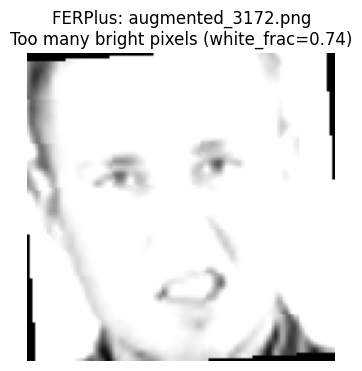


DROPPED: C:\Users\drnes\Downloads\EmotionClassifier-main\EmotionClassifier-main\datasets\FERPlus\train\angry\augmented_4627.png
Reason : Too many bright pixels (white_frac=0.67)
Shape  : (112, 112) | dtype: uint8


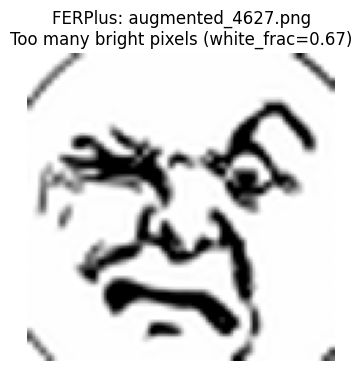


DROPPED: C:\Users\drnes\Downloads\EmotionClassifier-main\EmotionClassifier-main\datasets\FERPlus\train\fear\augmented_2028.png
Reason : Too bright (mean=235.8)
Shape  : (112, 112) | dtype: uint8


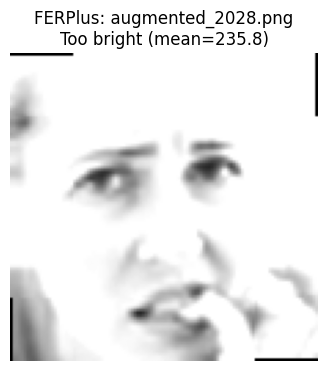


DROPPED: C:\Users\drnes\Downloads\EmotionClassifier-main\EmotionClassifier-main\datasets\FERPlus\train\fear\augmented_3675.png
Reason : Too many bright pixels (white_frac=0.67)
Shape  : (112, 112) | dtype: uint8


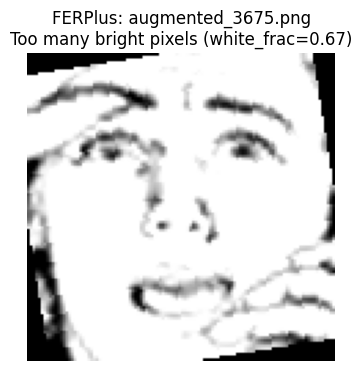


DROPPED: C:\Users\drnes\Downloads\EmotionClassifier-main\EmotionClassifier-main\datasets\FERPlus\train\fear\augmented_3876.png
Reason : Too many bright pixels (white_frac=0.71)
Shape  : (112, 112) | dtype: uint8


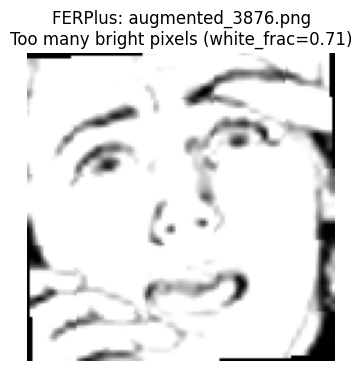


DROPPED: C:\Users\drnes\Downloads\EmotionClassifier-main\EmotionClassifier-main\datasets\FERPlus\train\fear\augmented_4515.png
Reason : Too many bright pixels (white_frac=0.72)
Shape  : (112, 112) | dtype: uint8


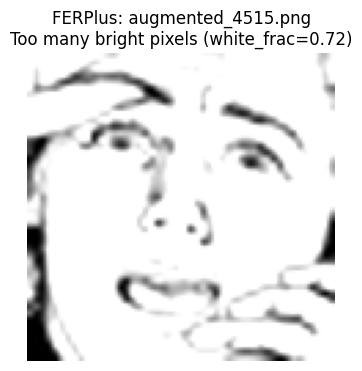


DROPPED: C:\Users\drnes\Downloads\EmotionClassifier-main\EmotionClassifier-main\datasets\FERPlus\train\fear\augmented_5302.png
Reason : Too many bright pixels (white_frac=0.60)
Shape  : (112, 112) | dtype: uint8


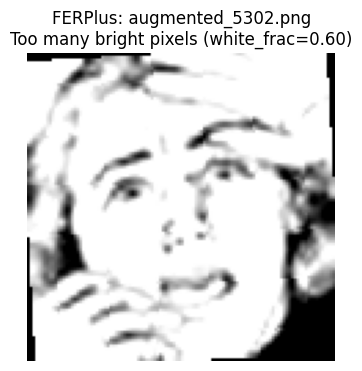

AffectNet dropped examples:

DROPPED: C:\Users\drnes\Downloads\EmotionClassifier-main\EmotionClassifier-main\datasets\AffectNet\Train\fear\image0038412.jpg
Reason : Too many dark pixels (black_frac=0.68)
Shape  : (96, 96, 3) | dtype: uint8


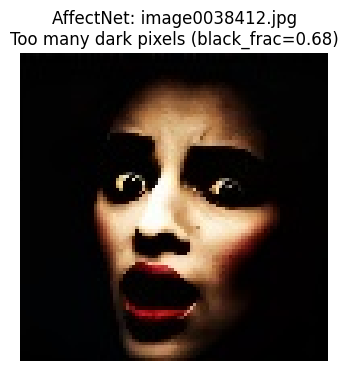


DROPPED: C:\Users\drnes\Downloads\EmotionClassifier-main\EmotionClassifier-main\datasets\AffectNet\Train\fear\image0039694.jpg
Reason : Too many dark pixels (black_frac=0.61)
Shape  : (96, 96, 3) | dtype: uint8


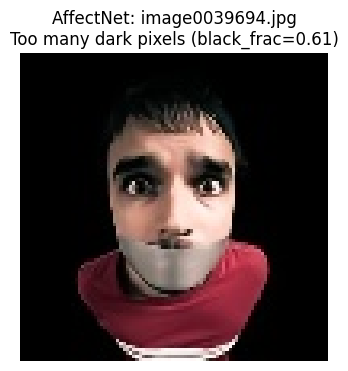


DROPPED: C:\Users\drnes\Downloads\EmotionClassifier-main\EmotionClassifier-main\datasets\AffectNet\Test\fear\image0019454.jpg
Reason : Too many dark pixels (black_frac=0.64)
Shape  : (96, 96, 3) | dtype: uint8


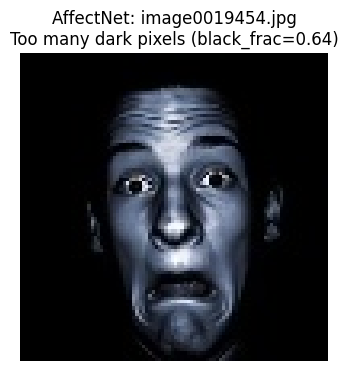

In [27]:
def show_dropped(dropped_list, title_prefix=""):
    if not dropped_list:
        print(title_prefix, "No dropped images found.")
        return

    for p, reason in dropped_list:
        img = cv2.imread(str(p), cv2.IMREAD_UNCHANGED)
        if img is None:
            print("READ FAILED:", p)
            continue

        print("\nDROPPED:", p)
        print("Reason :", reason)
        print("Shape  :", img.shape, "| dtype:", img.dtype)
        show(img, title=f"{title_prefix}{p.name}\n{reason}")

print("FERPlus dropped examples:")
show_dropped(dropped_fer, title_prefix="FERPlus: ")

print("AffectNet dropped examples:")
show_dropped(dropped_aff, title_prefix="AffectNet: ")


### ToRGB Demo

augmented_199.png | before: (112, 112) -> after: (112, 112, 3)


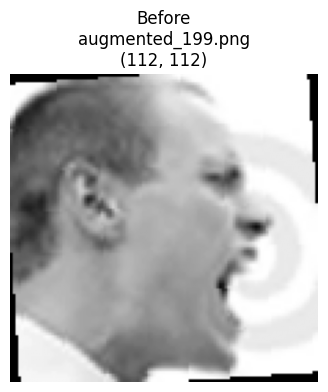

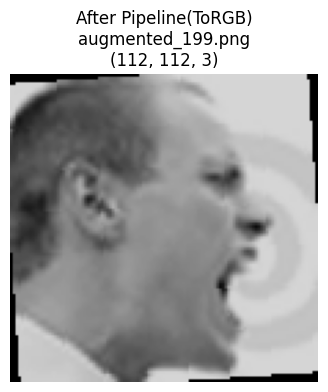

augmented_5195.png | before: (112, 112) -> after: (112, 112, 3)


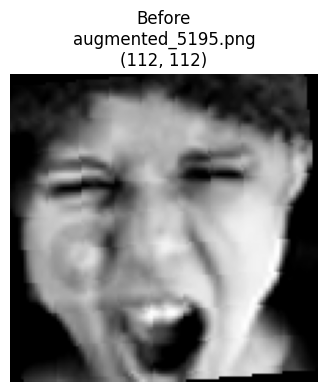

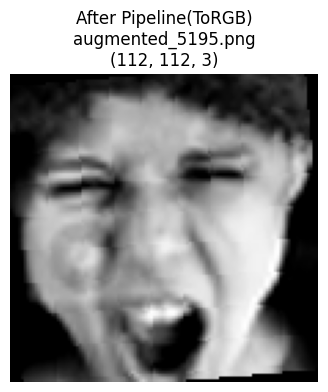

fer0017180.png | before: (112, 112) -> after: (112, 112, 3)


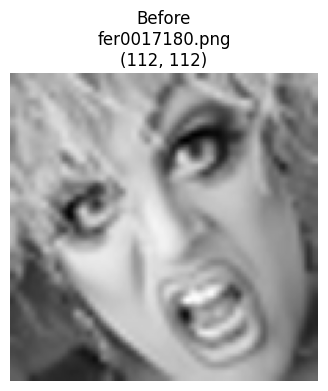

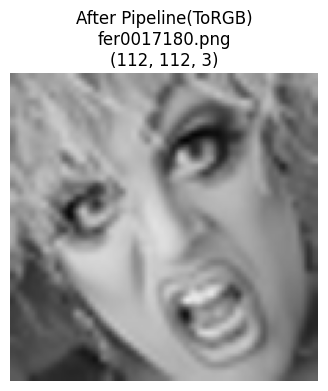

fer0012365.png | before: (112, 112) -> after: (112, 112, 3)


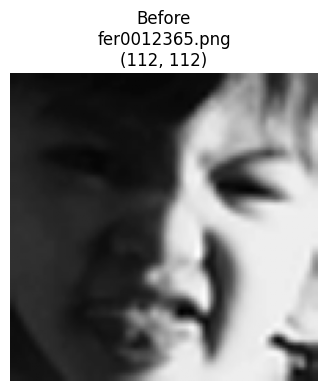

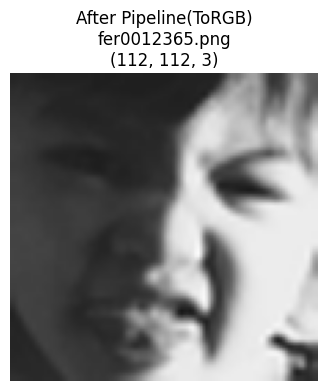

fer0008589.png | before: (112, 112) -> after: (112, 112, 3)


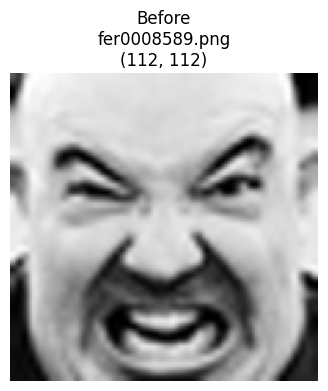

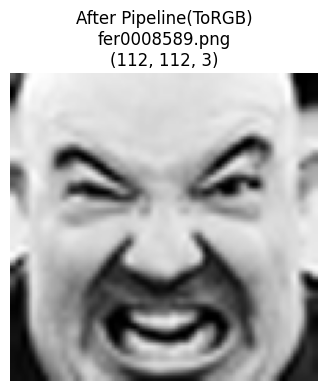

augmented_1463.png | before: (112, 112) -> after: (112, 112, 3)


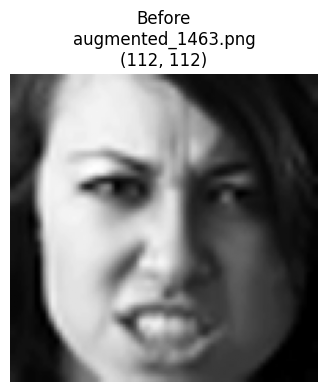

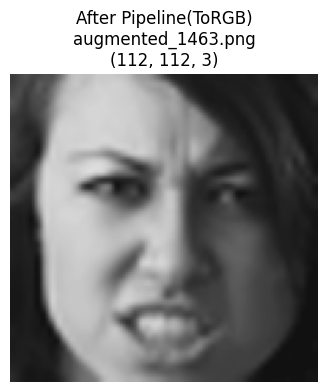

ffhq_4735.png | before: (96, 96, 3) -> after: (96, 96, 3)


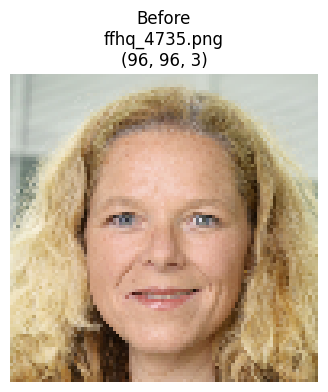

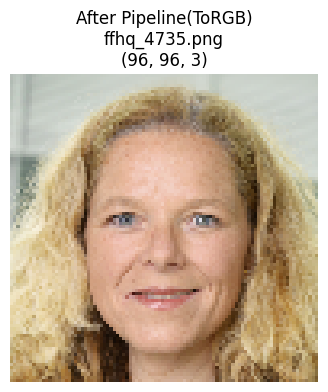

ffhq_3974.png | before: (96, 96, 3) -> after: (96, 96, 3)


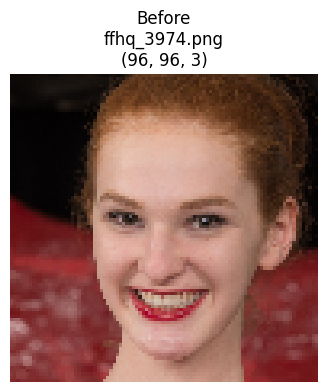

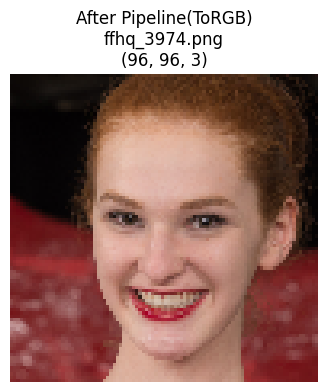

ffhq_4668.png | before: (96, 96, 3) -> after: (96, 96, 3)


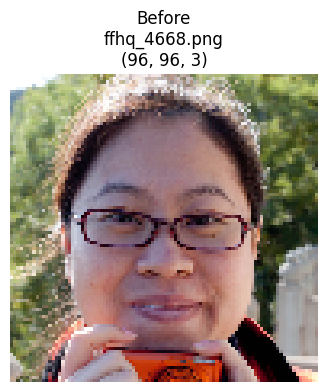

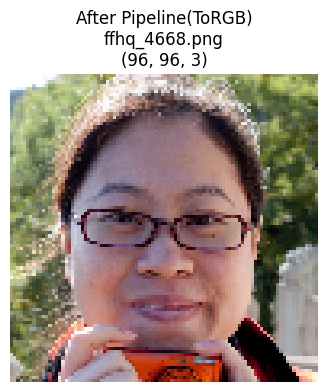

ffhq_3859.png | before: (96, 96, 3) -> after: (96, 96, 3)


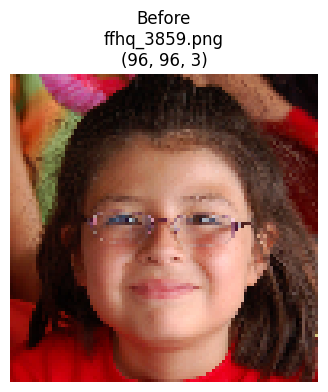

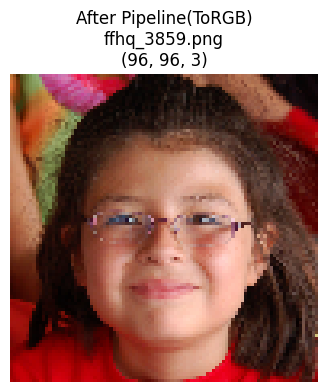

image0025142.jpg | before: (96, 96, 3) -> after: (96, 96, 3)


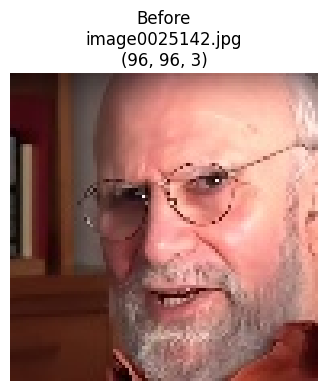

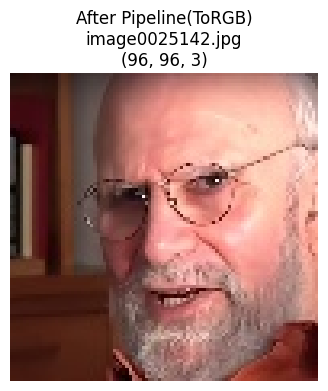

image0026902.jpg | before: (96, 96, 3) -> after: (96, 96, 3)


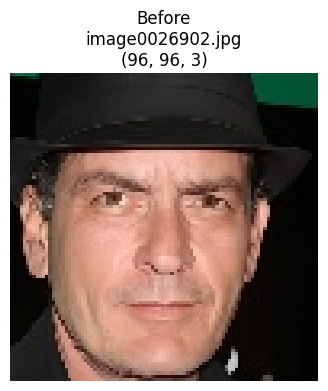

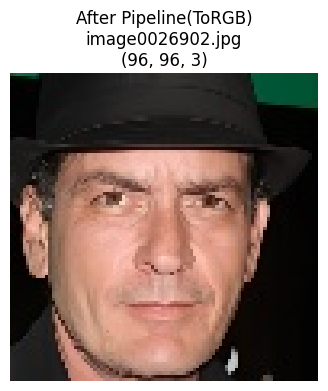

In [7]:
pipe = Pipeline([ToRGB()])

def demo_torgb_random_via_pipeline(dataset_key: str, n: int = 6, pool_size: int = 8000, seed: int = 0):
    random.seed(seed)
    root = DATASETS[dataset_key]
    paths = collect_images(root, max_files=pool_size)
    paths = random.sample(paths, k=min(n, len(paths)))

    for p in paths:
        img = cv2.imread(str(p), cv2.IMREAD_UNCHANGED)
        if img is None:
            print("READ FAILED:", p)
            continue

        out = pipe.execute(img)

        print(p.name, "| before:", img.shape, "-> after:", out.shape)
        show(img, title=f"Before\n{p.name}\n{img.shape}")
        show(out, title=f"After Pipeline(ToRGB)\n{p.name}\n{out.shape}")

demo_torgb_random_via_pipeline("ferplus_train", n=6, seed=1)
demo_torgb_random_via_pipeline("affectnet_train", n=6, seed=2)